In [1]:
import pandas as pd
import numpy as np
import sys
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from statsmodels.stats.multitest import multipletests

sys.path.append('..')
from utils import reshape_to_numpy, interpolate_missing_values, lowpass_filter

/home/marco/mnt/git/microtox/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sampling_rate = 100
lpf_cutoff = 10
lpf_order = 64

In [3]:
data = pd.read_parquet("../data/data.parquet")
data

,ride_id,time_index,participant_id,run,trial,ax,ay,az,rx,ry,rz,throttle,brake_l,brake_r
0,000e5ab725f4,0,23.0,Sober,2.0,-0.442073,-9.215956,-3.105285,0.020311,-0.136070,0.213650,41.0,41.0,41.0
1,000e5ab725f4,10,23.0,Sober,2.0,-0.547358,-9.390632,-2.988635,0.019853,-0.149967,0.210443,41.0,41.0,41.0
2,000e5ab725f4,20,23.0,Sober,2.0,-0.552742,-9.348757,-2.974876,0.017715,-0.165086,0.208457,41.0,41.0,41.0
3,000e5ab725f4,30,23.0,Sober,2.0,-0.605384,-9.287740,-3.065803,0.014508,-0.182190,0.206319,41.0,41.0,41.0
4,000e5ab725f4,40,23.0,Sober,2.0,-0.631106,-9.226125,-3.071786,0.014966,-0.197767,0.204181,41.0,41.0,41.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
876191,fdc39ec37c87,67410,13.0,Sober,2.0,1.475773,-10.374680,-0.763908,-0.276263,1.067486,0.098043,147.0,41.0,41.0
876192,fdc39ec37c87,67420,13.0,Sober,2.0,1.175474,-9.505487,-1.128814,-0.290924,1.067792,0.093462,147.0,41.0,41.0
876193,fdc39ec37c87,67430,13.0,Sober,2.0,1.273579,-10.332806,-0.802791,-0.313373,1.102611,0.105374,147.0,41.0,41.0
876194,fdc39ec37c87,67440,13.0,Sober,2.0,1.231107,-9.077770,-1.895115,-0.332616,1.102306,0.106443,147.0,41.0,41.0


In [4]:
labels = data.groupby(["ride_id", "participant_id"])["run"].first().reset_index()
labels

,ride_id,participant_id,run
0,000e5ab725f4,23.0,Sober
1,02a49cf28afc,31.0,High
2,04a58ca54c11,28.0,Sober
3,065ea8ad5f24,23.0,Low
4,097169d2138f,10.0,Low
...,...,...,...
136,fbf0250f1611,8.0,High
137,fc09a596ffcd,25.0,High
138,fcb8375a05a2,24.0,Low
139,fd0f1af171a2,23.0,Low


In [5]:
features = ["ax", "ay", "az", "rx", "ry", "rz", "throttle", "brake_l", "brake_r"]

data_np = reshape_to_numpy(
    data,
    features = features,
)

data_np_clean = interpolate_missing_values(
    data_np,
    method='linear',
    limit=None
)

data_np_lpf = lowpass_filter(
    data=data_np_clean,
    accel_indices=[0, 1, 2],
    gyro_indices=[3, 4, 5],
    accel_cutoff=lpf_cutoff,
    accel_order=lpf_order,
    gyro_cutoff=lpf_cutoff,
    gyro_order=lpf_order,
    fs=sampling_rate,
)

In [6]:
rows = []
for ride in tqdm(data_np_lpf):
    stds = []
    for ch in ride.T:
        ch = ch[~np.isnan(ch)] # trim trailing NaNs
        stds.append(np.std(ch))
    rows.append(stds)

X_feat = np.array(rows)
X_feat.shape

100%|██████████| 141/141 [00:00<00:00, 1868.92it/s]


(141, 9)

In [7]:
X_wsc = np.empty_like(X_feat)
for i in range(len(labels)):
    pid = labels["participant_id"].iloc[i]
    mask = (labels["participant_id"] == pid).values
    X_wsc[i] = X_feat[i] - X_feat[mask].mean(axis=0)

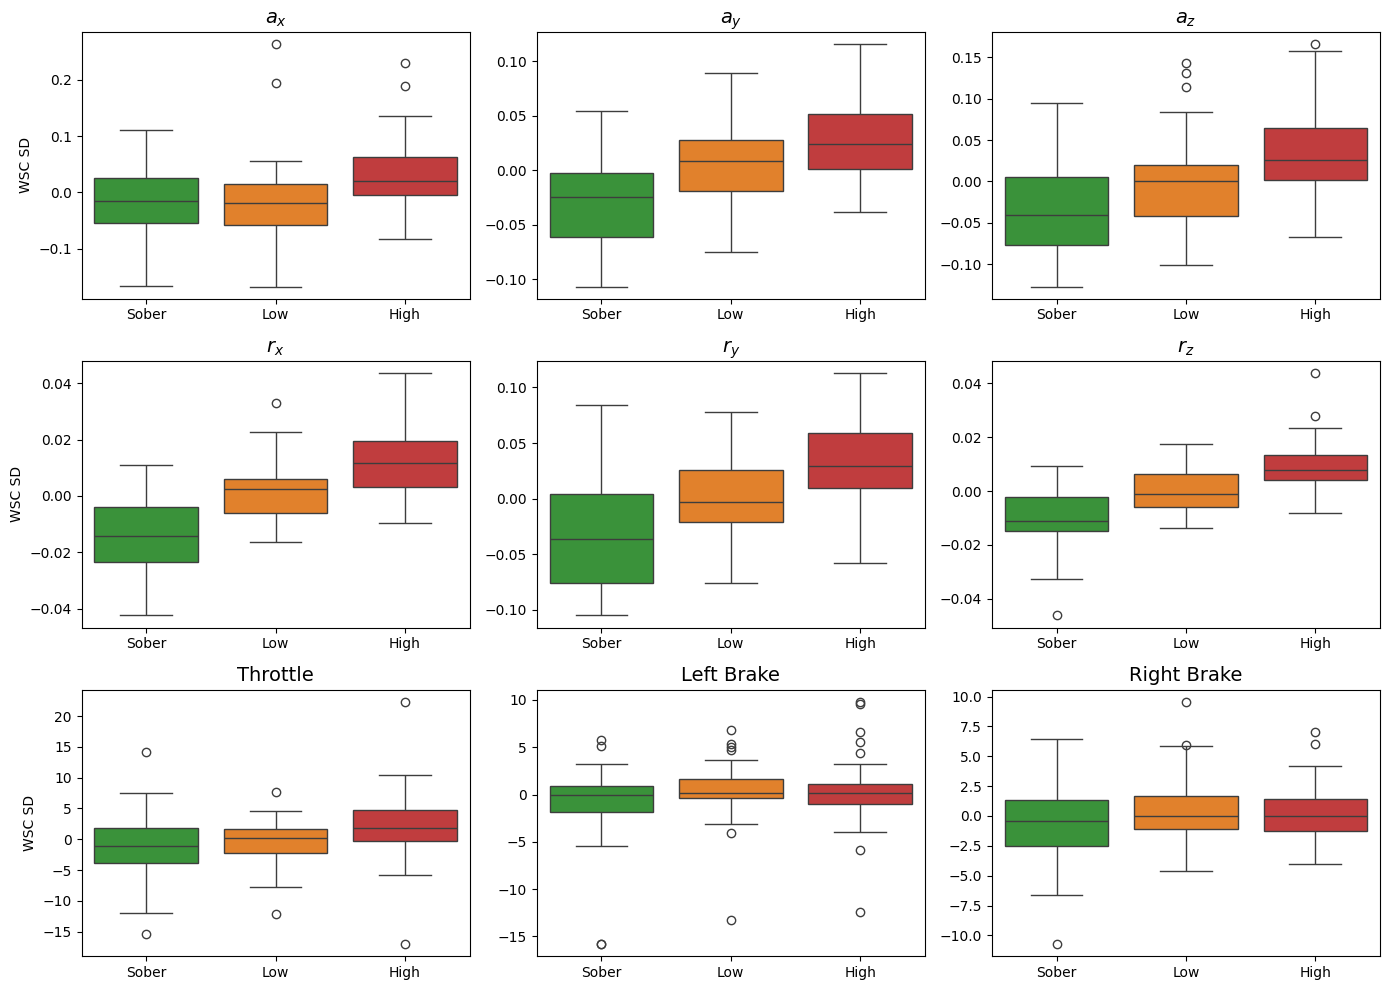

In [8]:
feat_df = pd.DataFrame(X_wsc, columns=features)
feat_df["Class"] = labels["run"].values

class_order = ["Sober", "Low", "High"]
class_palette = {"Sober": "#2ca02c", "Low": "#ff7f0e", "High": "#d62728"}

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, feat in zip(axes.flat, features):
    sns.boxplot(
        data=feat_df,
        x="Class",
        y=feat,
        hue="Class",
        order=class_order,
        hue_order=class_order,
        palette=class_palette,
        legend=False,
        ax=ax,
    )
    pretty = {"ax": r"$\mathit{a_x}$", "ay": r"$\mathit{a_y}$", "az": r"$\mathit{a_z}$",
               "rx": r"$\mathit{r_x}$", "ry": r"$\mathit{r_y}$", "rz": r"$\mathit{r_z}$",
               "brake_l": "Left Brake", "brake_r": "Right Brake"}
    ax.set_title(pretty.get(feat, feat.capitalize()), fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("WSC SD" if ax in axes[:, 0] else "")
plt.tight_layout()
fig.savefig("../figures/sd_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
dose = labels["run"].map({"Sober": 0, "Low": 1, "High": 2}).values
pid = labels["participant_id"].values
dose_rank = pd.Series(dose).rank().values

# rm_corr on ranks gives a non-parametric (Spearman-flavoured) coefficient
# while accounting for the trials-within-participants nesting via a random
# intercept per subject. Use raw X_feat (not X_wsc); rm_corr removes
# between-subject variance internally, so pre-centering would double-correct.
rs, ps = [], []
for j, feat in enumerate(features):
    df = pd.DataFrame({
        "pid": pid,
        "dose": dose_rank,
        "y": pd.Series(X_feat[:, j]).rank().values,
    })
    res = pg.rm_corr(data=df, x="dose", y="y", subject="pid")
    rs.append(float(res["r"].iloc[0]))
    ps.append(float(res["pval"].iloc[0]))

rs = np.array(rs)
ps = np.array(ps)

# rm_corr only returns two-sided p-values; convert to one-sided for the
# directional hypothesis H1: SD increases with dose (r_rm > 0). Valid because
# the null distribution of r_rm is symmetric.
p_one = np.where(rs > 0, ps / 2, 1 - ps / 2)

# Holm-Bonferroni controls FWER across the 9 channels without assuming
# independence (channels from the same sensor are correlated).
_, p_adj, _, _ = multipletests(p_one, method="holm")

print("Repeated-measures rank correlation (rm_corr on ranks, one-sided H1: r_rm > 0)")
print("Holm-Bonferroni corrected across the 9 channels\n")
print(f"{'feature':<10s} {'r_rm':>8s} {'p (Holm)':>12s}")
print("-" * 32)
for k, feat in enumerate(features):
    sig = " *" if p_adj[k] < 0.05 else ""
    print(f"{feat:<10s} {rs[k]:>8.3f} {p_adj[k]:>12.2e}{sig}")

Repeated-measures rank correlation (rm_corr on ranks, one-sided H1: r_rm > 0)
Holm-Bonferroni corrected across the 9 channels

feature        r_rm     p (Holm)
--------------------------------
ax            0.262     8.68e-03 *
ay            0.505     1.98e-08 *
az            0.429     3.51e-06 *
rx            0.649     1.07e-14 *
ry            0.560     1.75e-10 *
rz            0.613     7.81e-13 *
throttle      0.252     9.07e-03 *
brake_l       0.159     6.51e-02
brake_r       0.171     6.51e-02
